In [4]:
import sys
print(sys.executable)

/Users/leyudame/Documents/AIByDoing/.conda/bin/python


In [5]:
import numpy as np

x = np.array([56, 72, 69, 88, 102, 86, 76, 79, 94, 74])
y = np.array([92, 102, 86, 110, 130, 99, 96, 102, 105, 92])

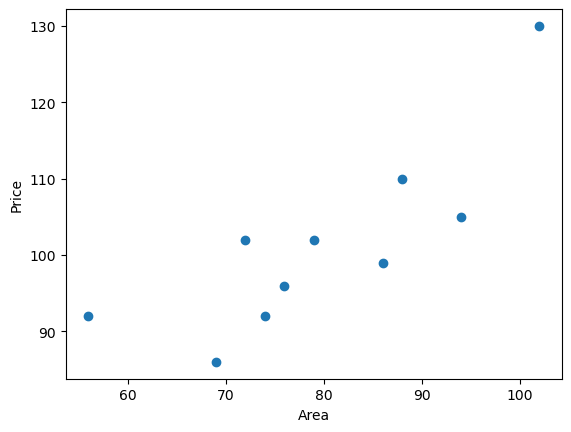

In [6]:
from matplotlib import pyplot as plt

%matplotlib inline

plt.scatter(x, y)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()  # 显示图像

In [7]:
def f(x: list, w0: float, w1: float):
    """一元一次函数表达式"""
    y = w0 + w1 * x
    return y

In [8]:
def square_loss(x: np.ndarray, y: np.ndarray, w0: float, w1: float):
    """平方损失函数"""
    loss = sum(np.square(y - (w0 + w1 * x)))
    return loss

In [9]:
def least_squares_algebraic(x: np.ndarray, y: np.ndarray):
    """最小二乘法代数求解"""
    n = x.shape[0]
    w1 = (n * sum(x * y) - sum(x) * sum(y)) / (n * sum(x * x) - sum(x) * sum(x))
    w0 = (sum(x * x) * sum(y) - sum(x) * sum(x * y)) / (
        n * sum(x * x) - sum(x) * sum(x)
    )
    return w0, w1

In [10]:
least_squares_algebraic(x, y)

(np.float64(41.33509168550616), np.float64(0.7545842753077117))

In [11]:
w0 = least_squares_algebraic(x, y)[0]
w1 = least_squares_algebraic(x, y)[1]

square_loss(x, y, w0, w1)

np.float64(447.69153479025357)

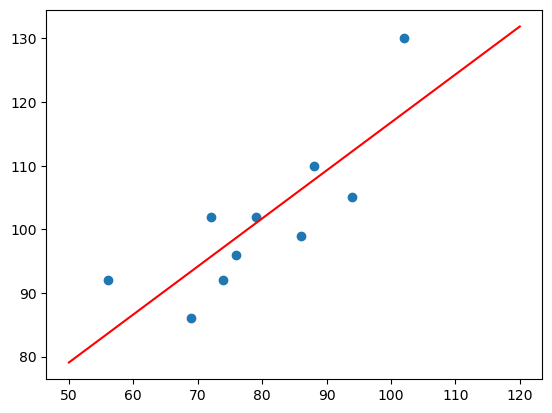

In [12]:
x_temp = np.linspace(50, 120, 100)  # 绘制直线生成的临时点

plt.scatter(x, y)
plt.plot(x_temp, x_temp * w1 + w0, "r")

In [13]:
f(150, w0, w1)

np.float64(154.5227329816629)

In [14]:
def least_squares_matrix(x: np.matrix, y: np.matrix):
    """最小二乘法矩阵求解"""
    w = (x.T * x).I * x.T * y
    return w

In [15]:
x_matrix = np.matrix(np.hstack((np.ones((x.shape[0], 1)), x.reshape(x.shape[0], 1))))
y_matrix = np.matrix(y.reshape(y.shape[0], 1))
x_matrix, y_matrix

(matrix([[  1.,  56.],
         [  1.,  72.],
         [  1.,  69.],
         [  1.,  88.],
         [  1., 102.],
         [  1.,  86.],
         [  1.,  76.],
         [  1.,  79.],
         [  1.,  94.],
         [  1.,  74.]]),
 matrix([[ 92],
         [102],
         [ 86],
         [110],
         [130],
         [ 99],
         [ 96],
         [102],
         [105],
         [ 92]]))

In [16]:
least_squares_matrix(x_matrix, y_matrix)

matrix([[41.33509169],
        [ 0.75458428]])